### Customer Segmentation for Solico Group
#### Project Overview
##### This project focuses on customer segmentation for Solico Group, using transaction data from January to June 2024. Due to confidentiality, the raw data cannot be shared. However, the methodology and insights are detailed here.

#### Data Description
#### The dataset includes:

##### Sales Value (IRR): Total spending by customers.
##### Purchase Frequency: How often customers make purchases.
##### Product Variety: The diversity of SKUs purchased by customers.
#### Objective
##### The goal of this analysis is to segment customers based on their purchasing behavior to enhance:

##### Targeted Marketing: Personalizing campaigns based on customer profiles.
##### Route & Resource Optimization: Efficiently allocating sales and distribution resources.
##### Operational Efficiency: Aligning inventory and demand forecasting with customer needs.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

### Load the Data

In [19]:
data=pd.read_excel ('Data.xlsx')

In [3]:
data.head()

,Customer_Code,Frequency,Variety,Sales
0,50001345,25.000000,107.666667,1.308532e+09
1,50004205,6.000000,25.000000,5.765494e+07
2,50004210,1.666667,12.000000,2.054651e+07
3,50004215,8.666667,31.333333,7.521765e+07
4,50004230,1.666667,7.000000,1.620038e+07


In [20]:
data['Customer_Code'] = data['Customer_Code'].astype(str)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90668 entries, 0 to 90667
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer_Code  90668 non-null  object 
 1   Frequency      90668 non-null  float64
 2   Variety        90668 non-null  float64
 3   Sales          90668 non-null  float64
dtypes: float64(3), object(1)
memory usage: 2.8+ MB


## Visualize the Data

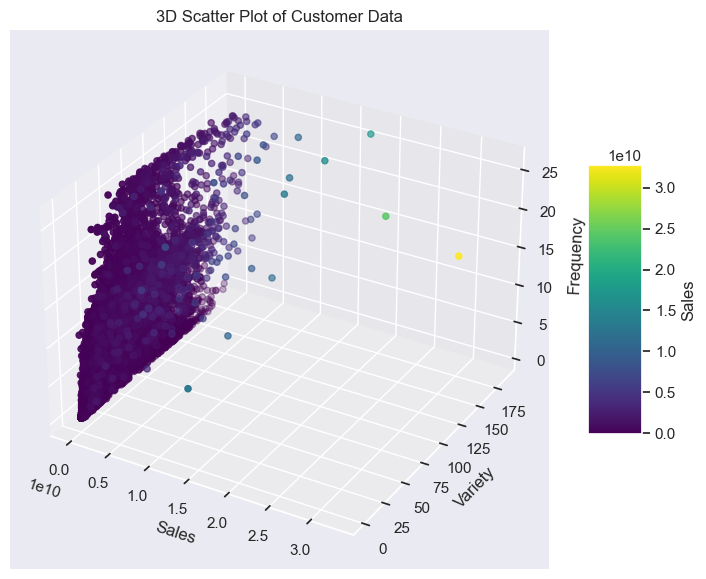

In [21]:

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(data['Sales'], data['Variety'], data['Frequency'], c=data['Sales'], cmap='viridis', marker='o')

ax.set_xlabel('Sales')
ax.set_ylabel('Variety')
ax.set_zlabel('Frequency')

colorbar = fig.colorbar(sc, ax=ax, shrink=0.5, aspect=5)
colorbar.set_label('Sales')

ax.set_title('3D Scatter Plot of Customer Data')

ax.grid(True)

plt.show()


## Select The Features

### KMean-Clustering

In [22]:
x = data.drop([ 'Customer_Code'], axis = 1)
#x = data.copy()

kmeans = KMeans(4)

kmeans.fit(x)

KMeans(n_clusters=4)

In [23]:
clusters = x.copy()

clusters['cluster_pred']=kmeans.fit_predict(x)

clusters.head()

,Frequency,Variety,Sales,cluster_pred
0,25.000000,107.666667,1.308532e+09,0
1,6.000000,25.000000,5.765494e+07,1
2,1.666667,12.000000,2.054651e+07,1
3,8.666667,31.333333,7.521765e+07,1
4,1.666667,7.000000,1.620038e+07,1


Text(0.5, 0, 'Frequency')

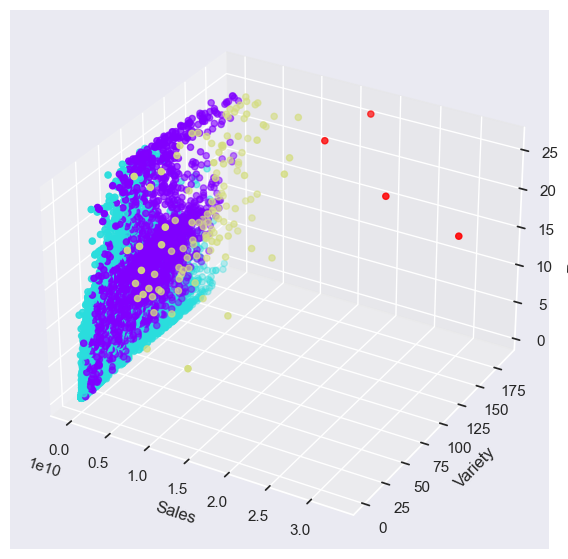

In [24]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')
ax.scatter(clusters['Sales'], clusters['Variety'], clusters['Frequency'],  c=clusters['cluster_pred'], cmap='rainbow')

ax.set_xlabel('Sales')
ax.set_ylabel('Variety')
ax.set_zlabel('Frequency')

## Standardize The Variables

In [25]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#x_scaled = preprocessing.scale(x)

x_scaled = pd.DataFrame(x_scaled, columns=['Frequency', 'Variety', 'Sales'])
x_scaled.head()

,Frequency,Variety,Sales
0,4.840984,4.018771,4.095387
1,-0.123987,-0.134170,-0.220043
2,-1.256349,-0.787253,-0.348064
3,0.572851,0.183999,-0.159453
4,-1.256349,-1.038439,-0.363058


## Applying the `Elbow Method`

##### The Elbow Method helps determine the optimal number of clusters in K-Means by plotting the Within-Cluster Sum of Squares (WCSS) for different k values. The "elbow point" is where adding more clusters no longer significantly reduces WCSS, indicating the best segmentation choice.

In [12]:
wcss =[]

for i in range(1,10):
 
    kmeans = KMeans(i)
   
    kmeans.fit(x_scaled)

    wcss.append(kmeans.inertia_)

wcss= pd.DataFrame(wcss, columns = ['WCSS'])
wcss

,WCSS
0,272004.000000
1,169703.930281
2,132947.364289
3,98745.218288
4,83400.383637
5,67579.875449
6,60640.585268
7,54093.715332
8,47645.267525


Text(0, 0.5, 'WCSS')

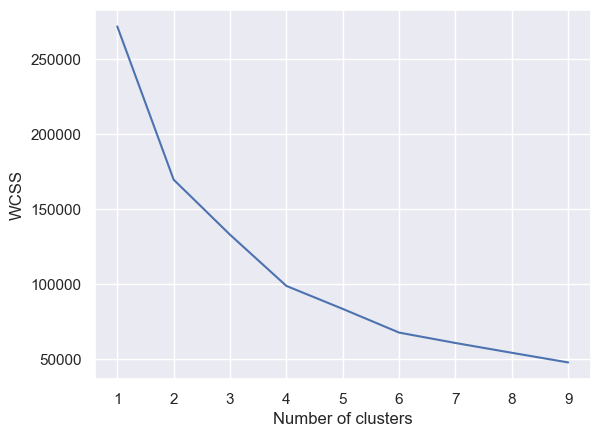

In [13]:
plt.plot(range(1,10),wcss)

plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

### Selecting the Number of Clusters (K)

In [26]:
kmeans_new = KMeans(5)

kmeans_new.fit(x_scaled)

clusters_new = data.copy()

clusters_new['cluster_pred'] = kmeans_new.fit_predict(x_scaled)

In [10]:
clusters_new

,Customer_Code,Frequency,Variety,Sales,cluster_pred
0,50001345,25.000000,107.666667,1.308532e+09,2
1,50004205,6.000000,25.000000,5.765494e+07,4
2,50004210,1.666667,12.000000,2.054651e+07,1
3,50004215,8.666667,31.333333,7.521765e+07,4
4,50004230,1.666667,7.000000,1.620038e+07,1
...,...,...,...,...,...
90663,450010310,1.666667,6.666667,3.403763e+08,1
90664,450010610,0.666667,4.000000,1.747017e+07,1
90665,450011740,6.666667,26.000000,7.745171e+07,4
90666,450013530,2.666667,41.000000,1.144918e+08,4


Text(0.5, 0, 'Frequency')

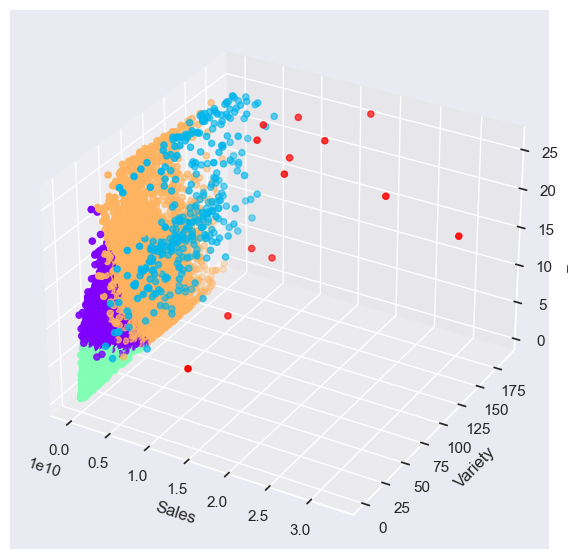

In [15]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')
ax.scatter(clusters_new['Sales'], clusters_new['Variety'], clusters_new['Frequency'],  c=clusters_new['cluster_pred'], cmap='rainbow')

ax.set_xlabel('Sales')
ax.set_ylabel('Variety')
ax.set_zlabel('Frequency')

In [11]:
clusters_new.to_excel('Clustering_New.xlsx', index=False)


In [17]:
clusters_new

,Customer_Code,Frequency,Variety,Sales,cluster_pred
0,50001345,25.000000,107.666667,1.308532e+09,1
1,50004205,6.000000,25.000000,5.765494e+07,0
2,50004210,1.666667,12.000000,2.054651e+07,2
3,50004215,8.666667,31.333333,7.521765e+07,0
4,50004230,1.666667,7.000000,1.620038e+07,2
...,...,...,...,...,...
90663,450010310,1.666667,6.666667,3.403763e+08,2
90664,450010610,0.666667,4.000000,1.747017e+07,2
90665,450011740,6.666667,26.000000,7.745171e+07,0
90666,450013530,2.666667,41.000000,1.144918e+08,2


##### I aligned the cluster labels (0, 1, 2, 3, 4) with the business-defined customer segments: VIP, A, B, C, and D.

In [29]:
group2 = clusters_new.groupby('cluster_pred')[['Frequency', 'Variety', 'Sales']].mean()
group2['Sales_M'] =group2['Sales']/1000000
group2

,Frequency,Variety,Sales,Sales_M
cluster_pred,,,,
0,8.449307,30.489354,1.174984e+08,117.498443
1,16.120952,105.673333,2.599875e+09,2599.875027
2,11.303921,64.645332,3.344673e+08,334.467261
3,19.307692,125.512821,1.449287e+10,14492.873563
4,3.222632,14.180207,4.075377e+07,40.753768


In [30]:
cluster_mapping = {
    3: 'VIP',
    1: 'A',
    2: 'B',
    4: 'D',
    0: 'C'
}

clusters_new['Cluster_Label'] = clusters_new['cluster_pred'].map(cluster_mapping)


In [31]:
clusters_new

,Customer_Code,Frequency,Variety,Sales,cluster_pred,Cluster_Label
0,50001345,25.000000,107.666667,1.308532e+09,1,A
1,50004205,6.000000,25.000000,5.765494e+07,0,C
2,50004210,1.666667,12.000000,2.054651e+07,4,D
3,50004215,8.666667,31.333333,7.521765e+07,0,C
4,50004230,1.666667,7.000000,1.620038e+07,4,D
...,...,...,...,...,...,...
90663,450010310,1.666667,6.666667,3.403763e+08,4,D
90664,450010610,0.666667,4.000000,1.747017e+07,4,D
90665,450011740,6.666667,26.000000,7.745171e+07,0,C
90666,450013530,2.666667,41.000000,1.144918e+08,4,D


In [23]:
clusters_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90668 entries, 0 to 90667
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer_Code  90668 non-null  object 
 1   Frequency      90668 non-null  float64
 2   Variety        90668 non-null  float64
 3   Sales          90668 non-null  float64
 4   cluster_pred   90668 non-null  int32  
 5   Cluster_Label  90668 non-null  object 
dtypes: float64(3), int32(1), object(2)
memory usage: 3.8+ MB


In [32]:
group = clusters_new.groupby('Cluster_Label')[['Frequency', 'Variety', 'Sales']].mean()


In [33]:
group['Sales_M'] =group['Sales']/1000000
group['Sales_M'] = group['Sales_M'].astype(int)
group['Frequency'] = group['Frequency'].astype(int)
group['Variety'] = group['Variety'].astype(int)


group

,Frequency,Variety,Sales,Sales_M
Cluster_Label,,,,
A,16,105,2.599875e+09,2599
B,11,64,3.344673e+08,334
C,8,30,1.174984e+08,117
D,3,14,4.075377e+07,40
VIP,19,125,1.449287e+10,14492


#### Above table shows the average of each feature in each cluster to provide a general understanding.

##### For sales, I added a Sales_M column, converting IRR to MIRR (Million Rial) for better readability.

#### Visualize Clusters by Sales

C:\Users\Saba\AppData\Local\Temp\ipykernel_23940\1419924087.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_sorted.index, y=group_sorted['Sales_M'], palette='Blues')


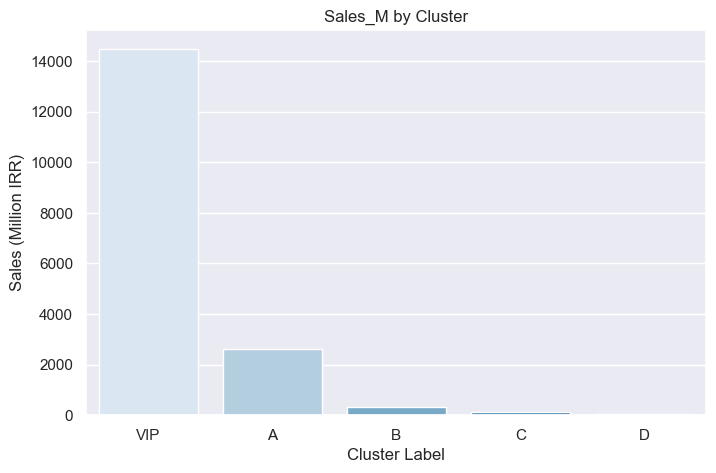

In [34]:

# Sorting clusters for better visualization
group_sorted = group.sort_values(by='Sales_M', ascending=False)

# Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=group_sorted.index, y=group_sorted['Sales_M'], palette='Blues')

# Labels
plt.xlabel('Cluster Label')
plt.ylabel('Sales (Million IRR)')
plt.title('Sales_M by Cluster')
plt.show()


### Heatmap for Feature Comparison


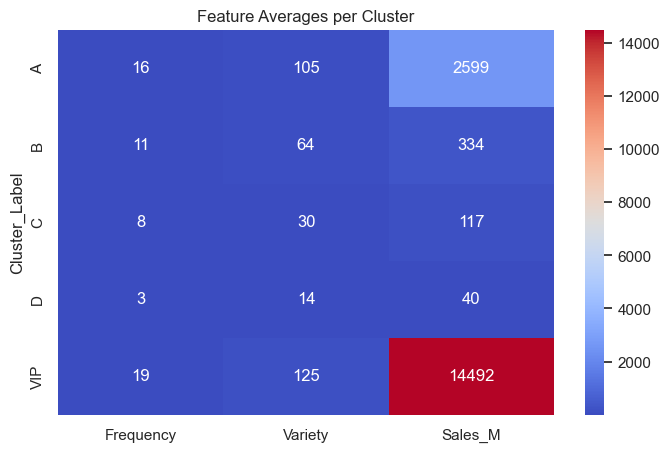

In [35]:
plt.figure(figsize=(8, 5))
sns.heatmap(group[['Frequency', 'Variety', 'Sales_M']], annot=True, cmap='coolwarm', fmt='g')
plt.title('Feature Averages per Cluster')
plt.show()
